In [1]:
import pandas as pd
import numpy as np
import json
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import zscore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", None)   # show all columns

#xdg-desktp-portal

In [2]:
DATA_PATH = "movies.csv"
df = pd.read_csv(DATA_PATH)

display(df.head(3))

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [3]:
print("=== General overview ===")
print(f"Objects (rows):   {df.shape[0]:,}")
print(f"Variables (cols): {df.shape[1]}")

data_types = [
    "nominal",   # index
    "ratio",     # budget
    "nominal",   # genres
    "nominal",   # homepage
    "nominal",   # id
    "nominal",   # keywords
    "nominal",   # original_language
    "nominal",   # original_title
    "nominal",   # overview
    "ratio",     # popularity
    "nominal",   # production_companies
    "nominal",   # production_countries
    "interval",  # release_date
    "ratio",     # revenue
    "ratio",     # runtime
    "nominal",   # spoken_languages
    "nominal",   # status
    "nominal",   # tagline
    "nominal",   # title
    "interval",  # vote_average
    "ratio",     # vote_count
    "nominal",   # cast
    "nominal",   # crew
    "nominal",   # director
]

print("\nColumns:")
max_len = max(len(c) for c in df.columns)
for c, lvl in zip(df.columns, data_types):
    print(f" - {c.ljust(max_len)}  {str(df[c].dtype).ljust(10)}  {lvl}")

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))
print(f"\nTotal missing cells: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")


=== General overview ===
Objects (rows):   4,803
Variables (cols): 24

Columns:
 - index                 int64       nominal
 - budget                int64       ratio
 - genres                str         nominal
 - homepage              str         nominal
 - id                    int64       nominal
 - keywords              str         nominal
 - original_language     str         nominal
 - original_title        str         nominal
 - overview              str         nominal
 - popularity            float64     ratio
 - production_companies  str         nominal
 - production_countries  str         nominal
 - release_date          str         interval
 - revenue               int64       ratio
 - runtime               float64     ratio
 - spoken_languages      str         nominal
 - status                str         nominal
 - tagline               str         nominal
 - title                 str         nominal
 - vote_average          float64     interval
 - vote_count            i

In [4]:
# treat " " as NaN
obj_cols = df.select_dtypes(include=["object", "string"]).columns
df[obj_cols] = df[obj_cols].replace(r"^\s*$", np.nan, regex=True)

# treat '0' in revenue, budget and runtime as NaN
for c in ["revenue", "budget", "runtime"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df.loc[df[c] == 0, c] = np.nan

missing_per_col = df.isna().sum()
missing_pct_per_col = (missing_per_col / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing": missing_per_col,
    "missing_%": missing_pct_per_col
}).sort_values("missing", ascending=False)

print("\nMissing values per column (after ' ' and 0 -> NaN):")
print(missing_summary)

total_missing = int(missing_per_col.sum())
total_cells = int(df.shape[0] * df.shape[1])
total_missing_pct = round(total_missing / total_cells * 100, 2)

print(f"\nTotal missing cells: {total_missing} / {total_cells} ({total_missing_pct}%)")
print(f"Duplicate rows: {int(df.duplicated().sum())}")


Missing values per column (after ' ' and 0 -> NaN):
                      missing  missing_%
homepage                 3091      64.36
revenue                  1427      29.71
budget                   1037      21.59
tagline                   844      17.57
keywords                  412       8.58
cast                       43       0.90
runtime                    37       0.77
director                   30       0.62
genres                     28       0.58
overview                    4       0.08
release_date                1       0.02
production_countries        0       0.00
production_companies        0       0.00
popularity                  0       0.00
original_title              0       0.00
spoken_languages            0       0.00
status                      0       0.00
original_language           0       0.00
title                       0       0.00
vote_average                0       0.00
vote_count                  0       0.00
id                          0       0.00
crew

## Possible reasons for missing data

**homepage**: Many movies don’t have an official homepage website. \
**tagline / keywords**: Optional metadata, which can be missing often for older, low-profile entries. \
**cast / director / genres**: Incomplete dataset, old movies, low profile movies. \
**budget / revenue = 0**: Commonly used as a placeholder for unknown / not reported. 

## Possible actions

**homepage**: drop the column.\
**tagline / keywords**: Ignore?..\
**cast / director / genres**: Remove those movies at all.\
**budget / revenue = 0**: Transform to "NaN"

In [5]:
# Manual decision:
# index - no need, we have 'id'
# original_title - most of the times is the same as 'title'
# status - more than 99% movies are 'Released'
released_n = df["status"].eq("Released").sum()
total_n = len(df)
print(f"Status = 'Released': {released_n}/{total_n} ({released_n/total_n*100:.2f}%) ")

Status = 'Released': 4795/4803 (99.83%) 


In [6]:
drop_cols = ["index", "original_title", "status"]

missing_rate = df.isna().mean()
drop_cols += missing_rate[missing_rate > 0.50].index.tolist()  # e.g., homepage

print("Suggested drop columns:", drop_cols)

df = df.drop(columns=drop_cols)

Suggested drop columns: ['index', 'original_title', 'status', 'homepage']


In [7]:
# Removing records which don't have cast, director or genres defined

df = df.dropna(subset=["cast", "director", "genres"])
print("Number of records:", df.shape[0])
df.to_csv("movies_cleaned.csv", index=False)
# print(df.columns)
# print(df.iloc[0])
# df.head(1)

Number of records: 4740


In [8]:
# Feature engineering - creating two new columns

df["profit"] = df["revenue"] - df["budget"]
df["prod_comp_amount"] = df["production_companies"].apply(lambda s: len(json.loads(s)))

In [9]:
# Display new dataset after removing and adding features

display(df.head(3))
print("Number of columns:", df.shape[1])
print("Number of records:", df.shape[0])

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,tagline,title,vote_average,vote_count,cast,crew,director,profit,prod_comp_amount
0,237000000.0,Action Adventure Fantasy Science Fiction,19995,culture clash future space war space colony so...,en,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2.787965e+09,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2.550965e+09,4
1,300000000.0,Adventure Fantasy Action,285,ocean drug abuse exotic island east india trad...,en,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,9.610000e+08,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,6.610000e+08,3
2,245000000.0,Action Adventure Crime,206647,spy based on novel secret agent sequel mi6,en,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,8.806746e+08,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,6.356746e+08,3


Number of columns: 22
Number of records: 4740


In [10]:
# Calculating outliers - IQR

num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop(["id", "popularity", "vote_average"])

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df[num_cols].lt(lower)) | (df[num_cols].gt(upper))

iqr_outliers = pd.DataFrame({
    "column": num_cols,
    "outliers": outlier_mask.sum().values,
    "outliers_%": (outlier_mask.mean() * 100).values,
    "lower": lower.values,
    "upper": upper.values,
}).sort_values("outliers", ascending=False)

iqr_outliers

,column,outliers,outliers_%,lower,upper
3,vote_count,498,10.506329,-9.803750e+02,1.788625e+03
4,profit,301,6.350211,-1.456397e+08,2.433825e+08
1,revenue,299,6.308017,-1.718994e+08,3.275355e+08
0,budget,245,5.168776,-5.500000e+07,1.130000e+08
2,runtime,147,3.101266,5.800000e+01,1.540000e+02
5,prod_comp_amount,103,2.172996,-3.500000e+00,8.500000e+00


In [11]:
# Calculating outliers - zscore

num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop(["id", "popularity", "vote_average"])

z_thresh = 3.0  # common default; you can try 2.5 or 3.5 as well

# compute z-scores per column (column-wise)
z = df[num_cols].apply(lambda s: zscore(s, nan_policy="omit"))

# mark outliers
z_outlier_mask = z.abs() > z_thresh

z_outliers = pd.DataFrame({
    "column": num_cols,
    "outliers": z_outlier_mask.sum().values,
    "outliers_%": (z_outlier_mask.mean() * 100).values,
    "z_threshold": [z_thresh] * len(num_cols),
}).sort_values("outliers", ascending=False)

z_outliers

,column,outliers,outliers_%,z_threshold
3,vote_count,123,2.594937,3.0
1,revenue,86,1.814346,3.0
0,budget,85,1.793249,3.0
4,profit,80,1.687764,3.0
2,runtime,73,1.540084,3.0
5,prod_comp_amount,57,1.202532,3.0


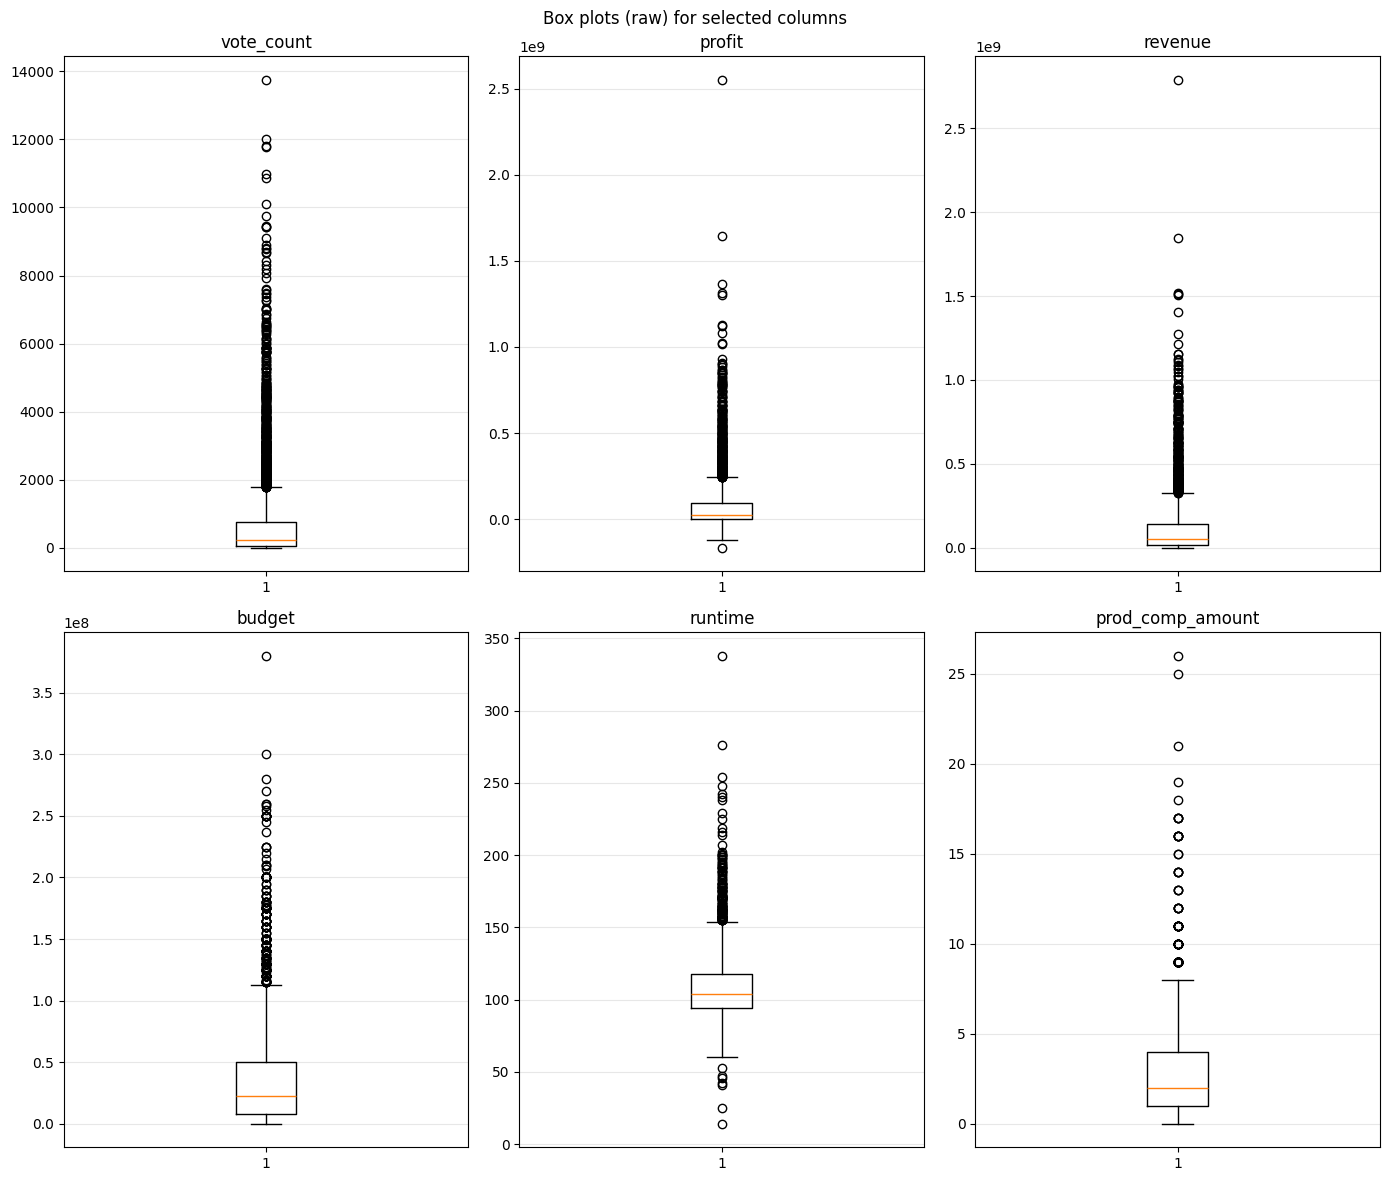

In [12]:
cols = ["vote_count", "profit", "revenue", "budget", "runtime", "prod_comp_amount"]
cols = [c for c in cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 12))
axes = axes.ravel()

for i, c in enumerate(cols):
    s = pd.to_numeric(df[c], errors="coerce").dropna()
    axes[i].boxplot(s, showfliers=True)
    axes[i].set_title(c)
    axes[i].grid(True, axis="y", alpha=0.3)

# If fewer than 6 columns exist, hide extra axes
for j in range(len(cols), 6):
    axes[j].axis("off")

fig.suptitle("Box plots (raw) for selected columns", y=0.98)
plt.tight_layout()
plt.show()


### Why each column can contain outliers

- **`vote_count`**: A small number of very popular movies accumulate disproportionately many votes. Voting follows a “winner-takes-most” pattern (blockbusters + cult classics).

- **`revenue`**. Box office revenue is extremely skewed: most movies earn modest amounts, a few earn hundreds of millions or more. These high values are meaningful (true blockbusters), not necessarily errors.

- **`budget`** Production budgets vary widely across genres and studios (indie vs. franchise films).

- **`profit`**  A few movies generate extremely large profits (or large losses), so extremes are normal.

- **`runtime`**.  Most feature films cluster around ~90–120 minutes, but valid movies can be shorter (short films) or much longer (epics, special cuts).

- **`prod_comp_amount`**. some movies genuinely have many production companies (co-productions).

# Data Visualization


### Popularity 

Popularity can seems ambiguous or unclear attribute. Its strict formula is unclear in the dataset, but usually it can cotain the following information:

- votes for the day
- views for the day
- favorites for the day
- watchlist adds for the day
- release date
- total votes
- previous day’s score
- ...

This is just movie engamenet score - some movies are popular and rewatched often, and some of them are only watched once.

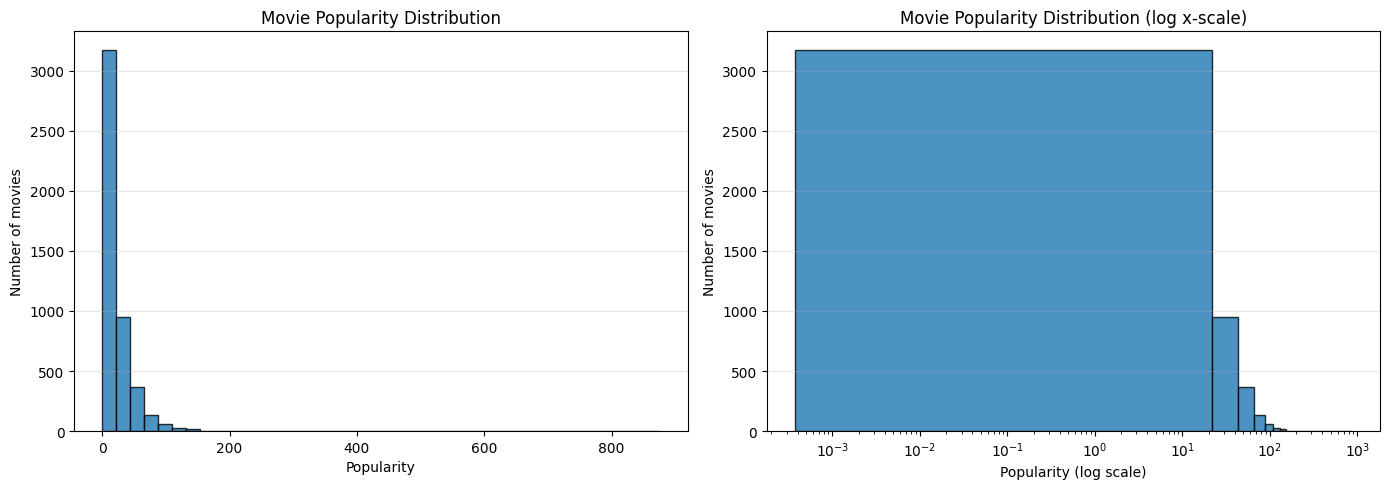

,title,popularity,release_date,vote_average,vote_count
0,Minions,875.581305,2015-06-17,6.4,4571
1,Interstellar,724.247784,2014-11-05,8.1,10867
2,Deadpool,514.569956,2016-02-09,7.4,10995
3,Guardians of the Galaxy,481.098624,2014-07-30,7.9,9742
4,Mad Max: Fury Road,434.278564,2015-05-13,7.2,9427
5,Jurassic World,418.708552,2015-06-09,6.5,8662
6,Pirates of the Caribbean: The Curse of the Bla...,271.972889,2003-07-09,7.5,6985
7,Dawn of the Planet of the Apes,243.791743,2014-06-26,7.3,4410
8,The Hunger Games: Mockingjay - Part 1,206.227151,2014-11-18,6.6,5584
9,Big Hero 6,203.734590,2014-10-24,7.8,6135


In [13]:
popularity = pd.to_numeric(df["popularity"], errors="coerce").dropna()
popularity_pos = popularity[popularity > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(popularity, bins=40, edgecolor="black", alpha=0.8)
axes[0].set_title("Movie Popularity Distribution")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Number of movies")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].hist(popularity_pos, bins=40, edgecolor="black", alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_title("Movie Popularity Distribution (log x-scale)")
axes[1].set_xlabel("Popularity (log scale)")
axes[1].set_ylabel("Number of movies")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



# Top 20 movies by popularity
top_20_popular = (
    df[["title", "popularity", "release_date", "vote_average", "vote_count"]]
    .copy()
)

top_20_popular["popularity"] = pd.to_numeric(top_20_popular["popularity"], errors="coerce")
top_20_popular = top_20_popular.dropna(subset=["popularity"])
top_20_popular = top_20_popular.sort_values("popularity", ascending=False).head(20)

display(top_20_popular.reset_index(drop=True))


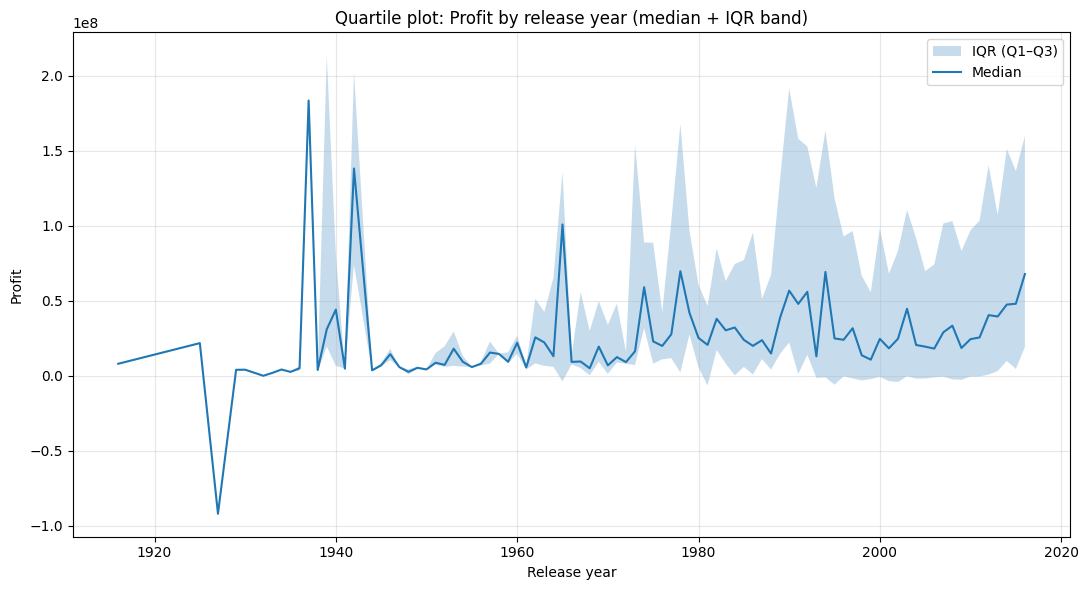

In [14]:
df["release_year"] = pd.to_datetime(df["release_date"], format="%Y-%m-%d", errors="coerce").dt.year

g = df.groupby("release_year")["profit"]
q1  = g.quantile(0.25)
med = g.quantile(0.50)
q3  = g.quantile(0.75)

plt.figure(figsize=(11, 6))
plt.fill_between(q1.index, q1.values, q3.values, alpha=0.25, label="IQR (Q1–Q3)")
plt.plot(med.index, med.values, label="Median")

plt.title("Quartile plot: Profit by release year (median + IQR band)")
plt.xlabel("Release year")
plt.ylabel("Profit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

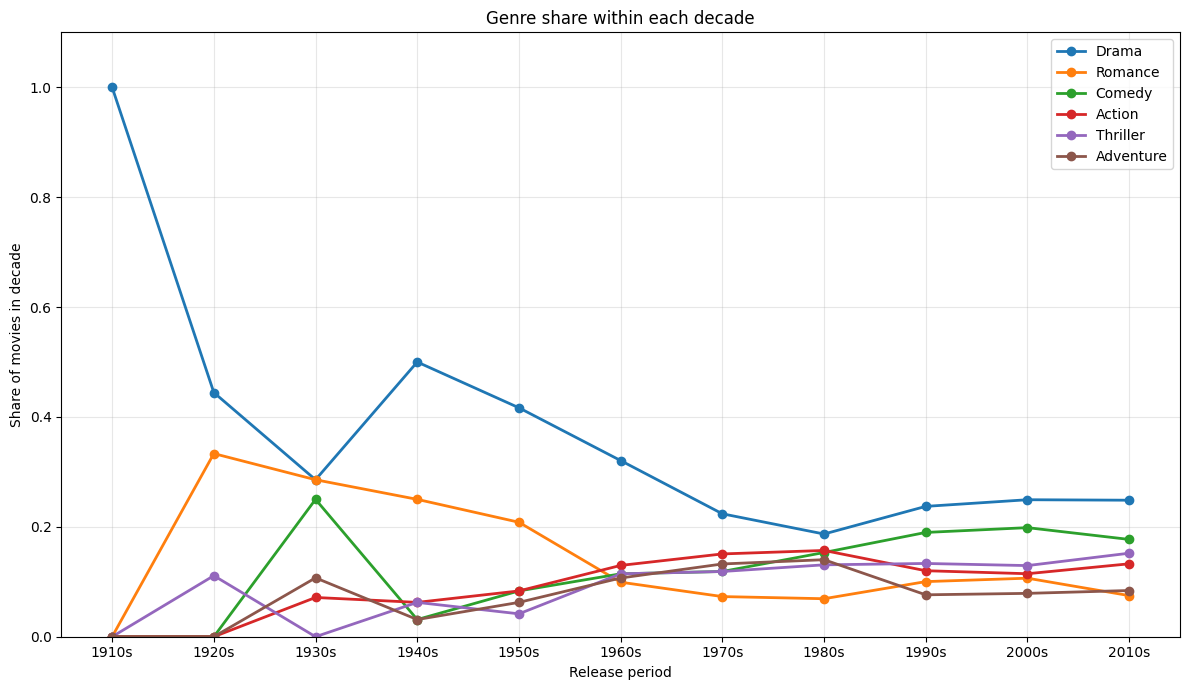

In [15]:
# Genre share by decade as a line chart only
import re

genre_catalog = [
    "Science Fiction", "TV Movie", "Action", "Adventure", "Animation",
    "Comedy", "Crime", "Documentary", "Drama", "Family", "Fantasy",
    "Foreign", "History", "Horror", "Music", "Mystery", "Romance",
    "Thriller", "War", "Western"
]
genre_pattern = re.compile("|".join(sorted(map(re.escape, genre_catalog), key=len, reverse=True)))

genre_time = df[["genres", "release_date"]].dropna().copy()
genre_time["release_year"] = pd.to_datetime(genre_time["release_date"], errors="coerce").dt.year
genre_time = genre_time.dropna(subset=["release_year"])
genre_time["release_year"] = genre_time["release_year"].astype(int)
genre_time["genre_list"] = genre_time["genres"].apply(lambda s: genre_pattern.findall(str(s)))
genre_time = genre_time.explode("genre_list").dropna(subset=["genre_list"])

genre_time["period"] = (genre_time["release_year"] // 10) * 10
genre_time["period"] = genre_time["period"].astype(str) + "s"

top_genres = genre_time["genre_list"].value_counts().head(8).index
plot_df = genre_time[genre_time["genre_list"].isin(top_genres)]

heatmap = (
    plot_df.groupby(["period", "genre_list"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_genres)
)

period_order = sorted(heatmap.index, key=lambda x: int(x[:-1]))
heatmap = heatmap.loc[period_order]

share_by_decade = heatmap.div(heatmap.sum(axis=1), axis=0).fillna(0)
top_line_genres = share_by_decade.mean().sort_values(ascending=False).head(6).index
share_plot = share_by_decade[top_line_genres]

plt.figure(figsize=(12, 7))

for genre in top_line_genres:
    plt.plot(
        share_plot.index,
        share_plot[genre],
        marker="o",
        linewidth=2,
        label=genre,
    )

plt.title("Genre share within each decade")
plt.xlabel("Release period")
plt.ylabel("Share of movies in decade")
plt.ylim(0, share_plot.to_numpy().max() * 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


,director,n_movies,total_profit,total_budget,ROI,hit_rate,score
458,Darren Lynn Bousman,5,4.321545e+08,2.400000e+07,18.006439,0.600000,3.732734
782,Guy Hamilton,6,4.787804e+08,2.870000e+07,16.682245,0.833333,3.621288
2087,Steven Spielberg,27,7.479893e+09,1.667500e+09,4.485693,0.962963,3.013626
879,James Cameron,7,5.136669e+09,7.469000e+08,6.877319,1.000000,2.873145
733,George Lucas,5,2.979337e+09,3.597770e+08,8.281065,1.000000,2.520988
1719,Peter Jackson,9,5.205643e+09,1.293000e+09,4.026019,0.888889,2.108301
906,James Wan,7,2.096615e+09,2.707000e+08,7.745160,0.714286,1.867011
1468,Michael Bay,12,4.422525e+09,1.410000e+09,3.136542,1.000000,1.733268
318,Chris Columbus,11,3.116632e+09,6.270000e+08,4.970704,0.636364,1.454535
357,Christopher Nolan,8,3.222483e+09,1.005000e+09,3.206451,1.000000,1.364385


,director,n_movies,total_gross,avg_gross,median_gross
1348,Steven Spielberg,27,9.147393e+09,3.387923e+08,303788635.0
1091,Peter Jackson,9,6.498643e+09,7.220714e+08,926287400.0
562,James Cameron,7,5.883569e+09,8.405099e+08,378882411.0
932,Michael Bay,12,5.832525e+09,4.860437e+08,392141783.0
225,Christopher Nolan,8,4.227483e+09,5.284354e+08,524669345.0
196,Chris Columbus,9,3.725632e+09,4.139591e+08,358991681.0
1206,Robert Zemeckis,13,3.590622e+09,2.762017e+08,244527583.0
470,George Lucas,5,3.339114e+09,6.678228e+08,775398007.0
1394,Tim Burton,14,3.337418e+09,2.383870e+08,120057058.0
1170,Ridley Scott,16,3.189558e+09,1.993474e+08,143134874.5


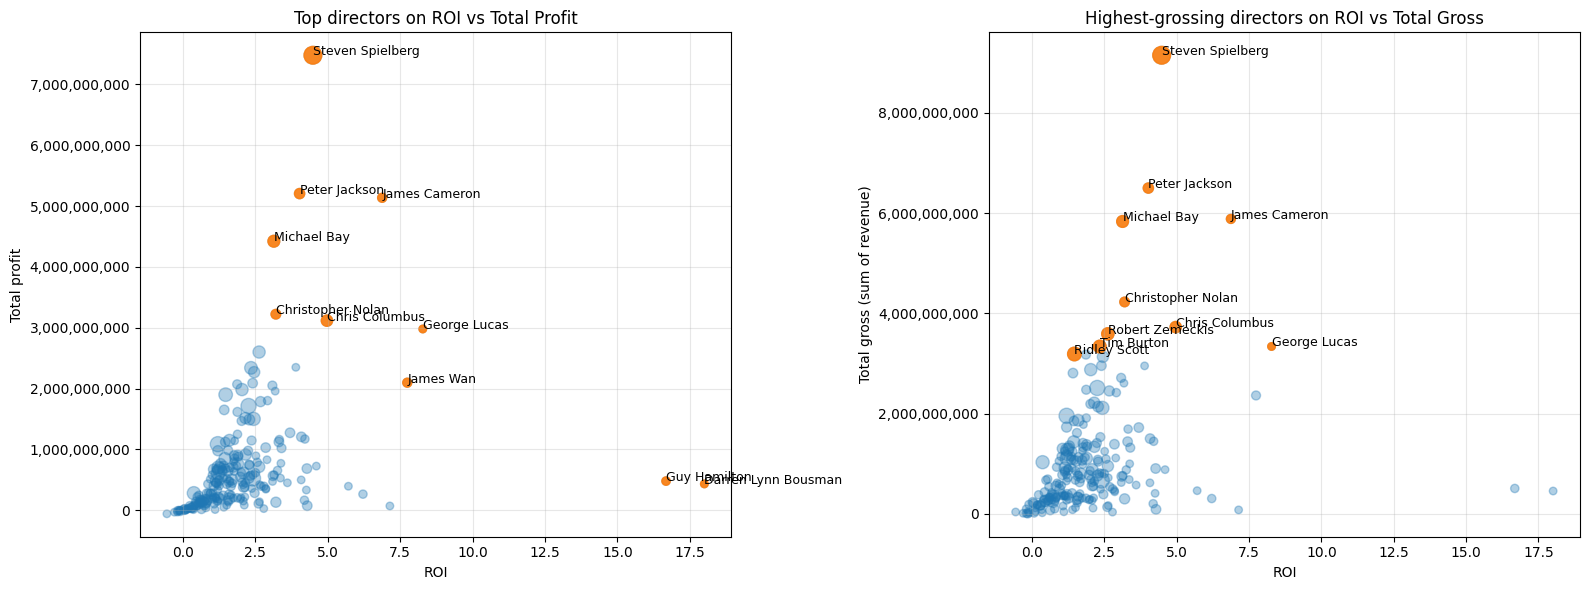

In [16]:
# Custom success metric:
#
# 0.5z(ROI) + 0.3z(profit) + 0.2(hit_rate)
# 
# ROI = profit / budget
# hit_rate = profitable movies / total movies by director       (share of movies with profit)
# 
# It combines how efficient a director is to make profit relative to budget; scale (how much profit earned); consistency (how often movies are profitable)
# Favors the directors that are not necessarily big, but also efficient and reliable

grp = df.groupby("director", as_index=False).agg(
    n_movies=("director", "size"),
    total_profit=("profit", "sum"),
    total_budget=("budget", "sum"),
    hit_rate=("profit", lambda s: (s > 0).mean()),
)

grp["ROI"] = grp["total_profit"] / grp["total_budget"].replace(0, np.nan)
metrics = grp[(grp["n_movies"] >= 5) & grp["ROI"].notna()].copy()

def zscore(s: pd.Series) -> pd.Series:
    mu = s.mean()
    sd = s.std(ddof=0)
    return (s - mu) / sd if sd != 0 else (s - mu) * 0

metrics["z_ROI"] = zscore(metrics["ROI"])
metrics["z_total_profit"] = zscore(metrics["total_profit"])
metrics["z_hit_rate"] = zscore(metrics["hit_rate"])

metrics["score"] = (
    0.5 * metrics["z_ROI"]
    + 0.3 * metrics["z_total_profit"]
    + 0.2 * metrics["z_hit_rate"]
)

top_score = metrics.sort_values("score", ascending=False).head(10)
display(top_score[["director", "n_movies", "total_profit", "total_budget", "ROI", "hit_rate", "score"]])

# 2. Highest grossing directors
d = df.copy()
d["director"] = d["director"].astype("string")
d["revenue"] = pd.to_numeric(d["revenue"], errors="coerce")
d = d[d["director"].notna() & np.isfinite(d["revenue"])]

gross_grp = d.groupby("director", as_index=False).agg(
    n_movies=("revenue", "size"),
    total_gross=("revenue", "sum"),
    avg_gross=("revenue", "mean"),
    median_gross=("revenue", "median"),
)

top_total = gross_grp[gross_grp["n_movies"] >= 5].sort_values("total_gross", ascending=False).head(10)
display(top_total)

tmp = df[["director", "revenue"]].copy()
tmp["revenue"] = pd.to_numeric(tmp["revenue"], errors="coerce")

gross = (
    tmp.dropna(subset=["director"])
       .groupby("director", as_index=False)
       .agg(total_gross=("revenue", "sum"))
)

metrics_gross = metrics.merge(gross, on="director", how="left")
metrics_gross = metrics_gross[np.isfinite(metrics_gross["total_gross"])].copy()

annot_score = metrics.sort_values("score", ascending=False).head(10)
annot_gross = metrics_gross.sort_values("total_gross", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: ROI vs Total Profit
axes[0].scatter(metrics["ROI"], metrics["total_profit"], s=metrics["n_movies"] * 6, alpha=0.35)
axes[0].scatter(annot_score["ROI"], annot_score["total_profit"], s=annot_score["n_movies"] * 6, alpha=0.9)

for _, r in annot_score.iterrows():
    axes[0].text(r["ROI"], r["total_profit"], r["director"], fontsize=9)

axes[0].set_title("Top directors on ROI vs Total Profit")
axes[0].set_xlabel("ROI")
axes[0].set_ylabel("Total profit")
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(style="plain", axis="y", useOffset=False)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# Right: ROI vs Total Gross
axes[1].scatter(metrics_gross["ROI"], metrics_gross["total_gross"], s=metrics_gross["n_movies"] * 6, alpha=0.35)
axes[1].scatter(annot_gross["ROI"], annot_gross["total_gross"], s=annot_gross["n_movies"] * 6, alpha=0.9)

for _, r in annot_gross.iterrows():
    axes[1].text(r["ROI"], r["total_gross"], r["director"], fontsize=9)

axes[1].set_title("Highest-grossing directors on ROI vs Total Gross")
axes[1].set_xlabel("ROI")
axes[1].set_ylabel("Total gross (sum of revenue)")
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style="plain", axis="y", useOffset=False)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()


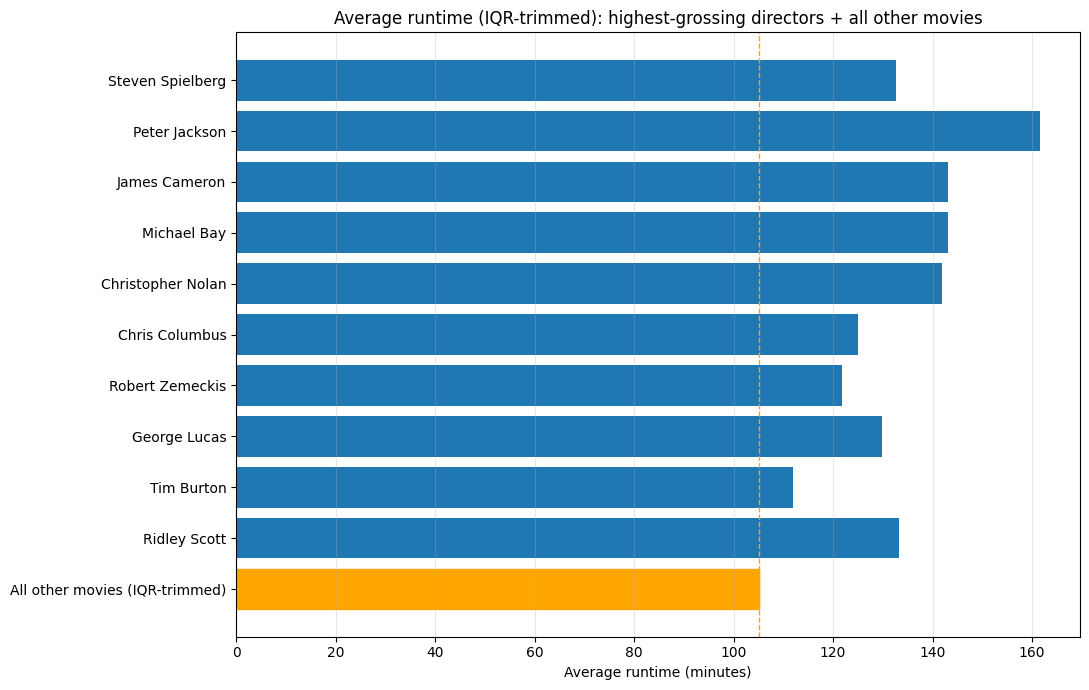

In [17]:
top_dirs = top_total["director"].tolist()

def iqr_bounds(a, k=1.5):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if len(a) == 0:
        return np.nan, np.nan
    q1 = np.percentile(a, 25)
    q3 = np.percentile(a, 75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# --- Top directors: avg runtime AFTER IQR trimming within each director ---
tmp = df.loc[df["director"].isin(top_dirs), ["director", "runtime"]].copy()
tmp["runtime"] = pd.to_numeric(tmp["runtime"], errors="coerce")
tmp = tmp[np.isfinite(tmp["runtime"])]

def iqr_trim_mean(s, k=1.5):
    lo, hi = iqr_bounds(s.to_numpy(), k=k)
    s2 = s[(s >= lo) & (s <= hi)]
    return float(s2.mean()) if len(s2) else np.nan

avg_rt = tmp.groupby("director", as_index=False).agg(
    avg_runtime=("runtime", lambda s: iqr_trim_mean(s, k=1.5))
)

# keep the same ordering as top_total
plot_df = top_total[["director"]].merge(avg_rt, on="director", how="left").dropna(subset=["avg_runtime"])

# --- All other movies: IQR-trimmed mean runtime (global, excluding top directors) ---
other = df.loc[~df["director"].isin(top_dirs), ["runtime"]].copy()
other["runtime"] = pd.to_numeric(other["runtime"], errors="coerce")
other = other[np.isfinite(other["runtime"])]

other_lo, other_hi = iqr_bounds(other["runtime"].to_numpy(), k=1.5)
other_trim = other[(other["runtime"] >= other_lo) & (other["runtime"] <= other_hi)]
other_avg_runtime = other_trim["runtime"].mean()

other_row = pd.DataFrame({
    "director": ["All other movies (IQR-trimmed)"],
    "avg_runtime": [other_avg_runtime],
})

plot_df2 = pd.concat([plot_df, other_row], ignore_index=True)

# reverse for nicer top-to-bottom ordering
plot_rev = plot_df2.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_rev["director"], plot_rev["avg_runtime"])

# color just the "All other movies" bar orange
for i, d in enumerate(plot_rev["director"]):
    if d.startswith("All other movies"):
        bars[i].set_color("orange")

# vertical reference line at the (IQR-trimmed) "All other movies" avg runtime
if np.isfinite(other_avg_runtime):
    ax.axvline(other_avg_runtime, linestyle="--", linewidth=1, color="orange")

ax.set_title("Average runtime (IQR-trimmed): highest-grossing directors + all other movies")
ax.set_xlabel("Average runtime (minutes)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Points used: 4331
Pearson corr(runtime, popularity) = 0.2293


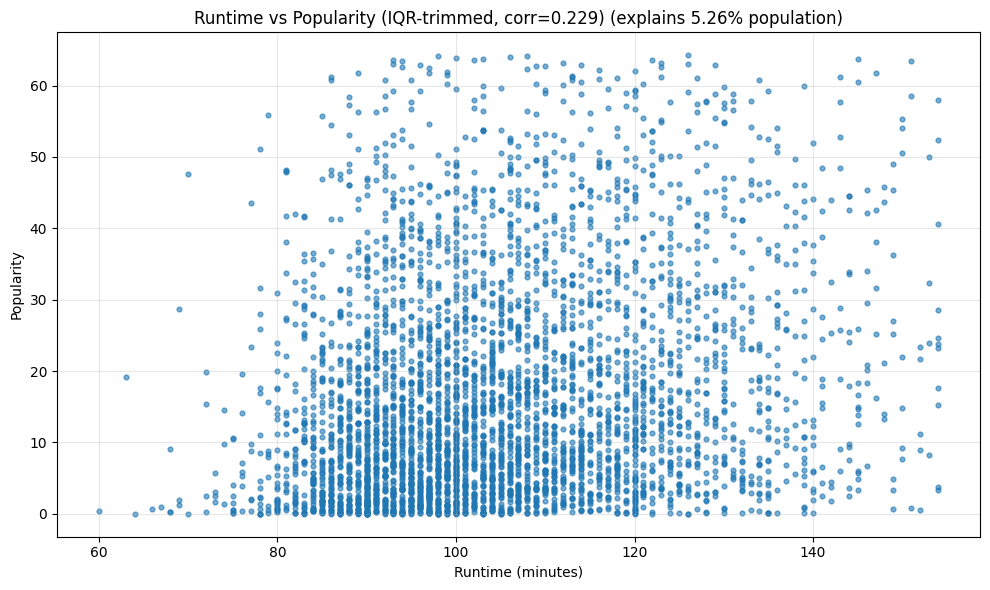

In [18]:
x = pd.to_numeric(df["runtime"], errors="coerce").to_numpy()
y = pd.to_numeric(df["popularity"], errors="coerce").to_numpy()

# keep only finite pairs
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# --- IQR trim on BOTH runtime and popularity (pairwise) ---
def iqr_bounds(a, k=1.5):
    q1 = np.nanpercentile(a, 25)
    q3 = np.nanpercentile(a, 75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

x_lo, x_hi = iqr_bounds(x, k=1.5)
y_lo, y_hi = iqr_bounds(y, k=1.5)

iqr_mask = (x >= x_lo) & (x <= x_hi) & (y >= y_lo) & (y <= y_hi)
x = x[iqr_mask]
y = y[iqr_mask]
# --- end trim ---

corr = np.corrcoef(x, y)[0, 1]
print("Points used:", len(x))
print(f"Pearson corr(runtime, popularity) = {corr:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=12, alpha=0.6)

# trend line (with fallback)
try:
    m, b = np.polyfit(x, y, 1)
except np.linalg.LinAlgError:
    A = np.column_stack([x, np.ones_like(x)])
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]

# xx = np.linspace(x.min(), x.max(), 200)
# plt.plot(xx, m * xx + b)

plt.title(f"Runtime vs Popularity (IQR-trimmed, corr={corr:.3f}) (explains {corr**2*100:.2f}% population)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Popularity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

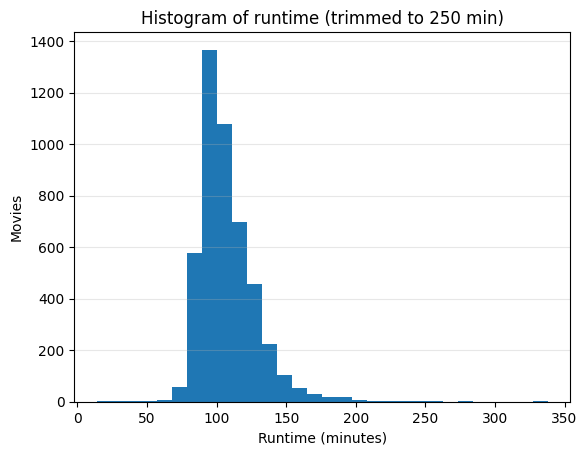

In [24]:
runtime = pd.to_numeric(df["runtime"], errors="coerce").dropna()
runtime = runtime[runtime < 400]  # trim very long movies

plt.figure()
plt.hist(runtime, bins=30)
plt.title("Histogram of runtime (trimmed to 250 min)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Movies")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Spearman corr(prod_comp_amount, profit) = 0.0980
Spearman corr(prod_comp_amount, vote_average) = 0.0472


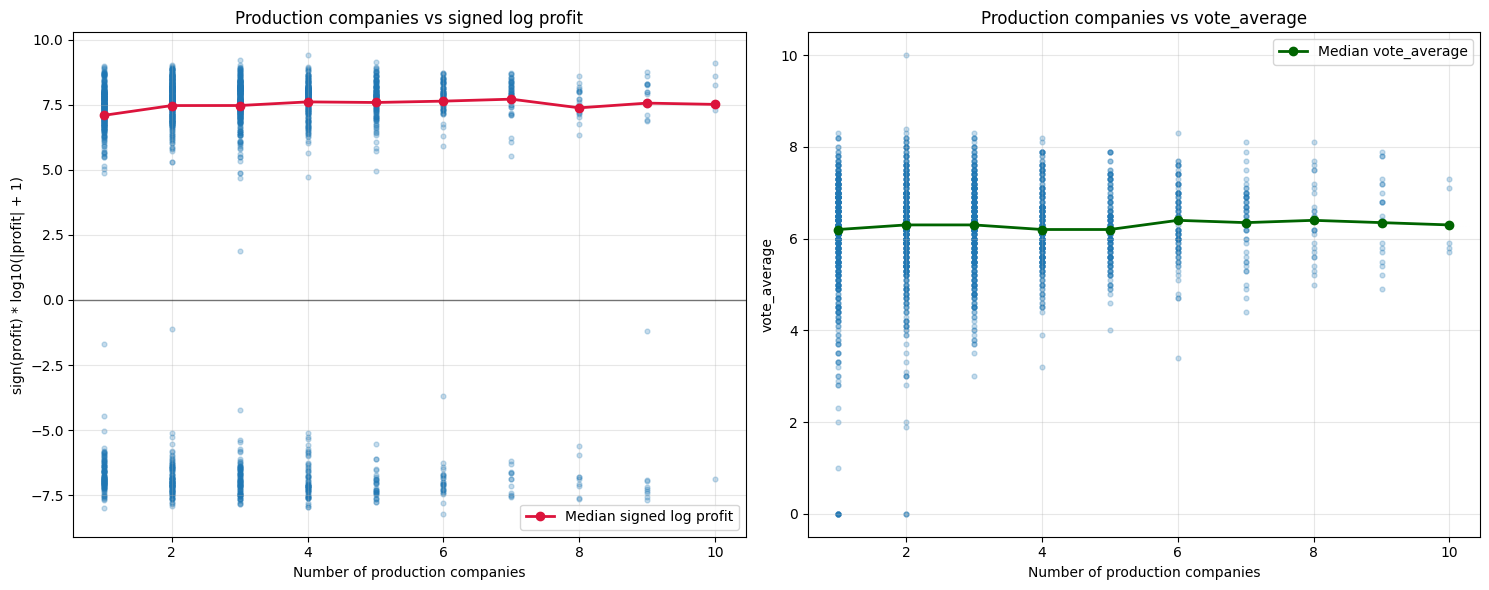

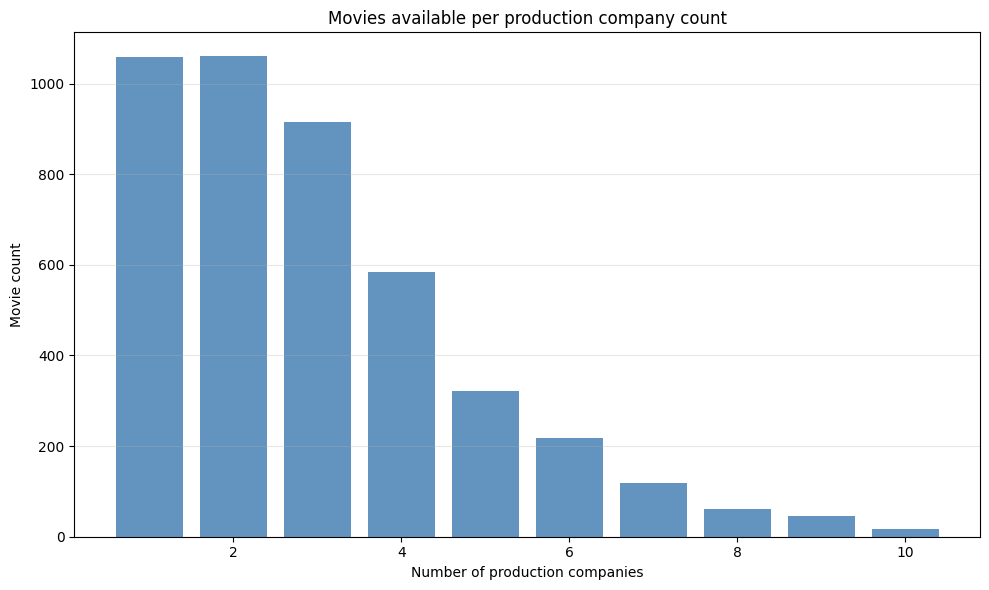

In [20]:

# Production companies vs signed log profit and vote_average side by side
base_df = df[["prod_comp_amount", "profit", "vote_average"]].copy()
base_df["prod_comp_amount"] = pd.to_numeric(base_df["prod_comp_amount"], errors="coerce")
base_df["profit"] = pd.to_numeric(base_df["profit"], errors="coerce")
base_df["vote_average"] = pd.to_numeric(base_df["vote_average"], errors="coerce")
base_df = base_df.dropna(subset=["prod_comp_amount"])
base_df = base_df[base_df["prod_comp_amount"] > 0]

# Limit x-axis to common range
x_cap = int(base_df["prod_comp_amount"].quantile(0.99))
base_df = base_df[base_df["prod_comp_amount"] <= x_cap].copy()

signed_log10 = lambda s: np.sign(s) * np.log10(np.abs(s) + 1)

profit_df = base_df.dropna(subset=["profit"]).copy()
profit_df["profit_log"] = signed_log10(profit_df["profit"])
profit_summary = profit_df.groupby("prod_comp_amount", as_index=False).agg(
    median_profit_log=("profit_log", "median"),
)

vote_df = base_df.dropna(subset=["vote_average"]).copy()
vote_summary = vote_df.groupby("prod_comp_amount", as_index=False).agg(
    median_vote_average=("vote_average", "median"),
)

profit_corr = profit_df[["prod_comp_amount", "profit"]].corr(method="spearman").iloc[0, 1]
vote_corr = vote_df[["prod_comp_amount", "vote_average"]].corr(method="spearman").iloc[0, 1]

print(f"Spearman corr(prod_comp_amount, profit) = {profit_corr:.4f}")
print(f"Spearman corr(prod_comp_amount, vote_average) = {vote_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

profit_sample = profit_df.sample(min(2000, len(profit_df)), random_state=42)
axes[0].scatter(profit_sample["prod_comp_amount"], profit_sample["profit_log"], s=12, alpha=0.25)
axes[0].plot(
    profit_summary["prod_comp_amount"],
    profit_summary["median_profit_log"],
    color="crimson",
    linewidth=2,
    marker="o",
    label="Median signed log profit",
)
axes[0].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0].set_title("Production companies vs signed log profit")
axes[0].set_xlabel("Number of production companies")
axes[0].set_ylabel("sign(profit) * log10(|profit| + 1)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

vote_sample = vote_df.sample(min(2000, len(vote_df)), random_state=42)
axes[1].scatter(vote_sample["prod_comp_amount"], vote_sample["vote_average"], s=12, alpha=0.25)
axes[1].plot(
    vote_summary["prod_comp_amount"],
    vote_summary["median_vote_average"],
    color="darkgreen",
    linewidth=2,
    marker="o",
    label="Median vote_average",
)
axes[1].set_title("Production companies vs vote_average")
axes[1].set_xlabel("Number of production companies")
axes[1].set_ylabel("vote_average")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Movies available per production company count in general
count_summary = base_df.groupby("prod_comp_amount", as_index=False).agg(
    movie_count=("prod_comp_amount", "size")
)

plt.figure(figsize=(10, 6))
plt.bar(count_summary["prod_comp_amount"], count_summary["movie_count"], color="steelblue", alpha=0.85)
plt.title("Movies available per production company count")
plt.xlabel("Number of production companies")
plt.ylabel("Movie count")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


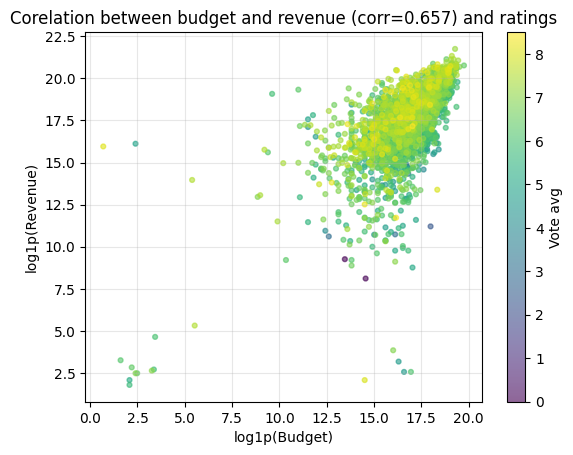

In [23]:
x = pd.to_numeric(df["budget"], errors="coerce")
y = pd.to_numeric(df["revenue"], errors="coerce")

mask = x.notna() & y.notna() & (x >= 0) & (y >= 0)
x = np.log1p(x[mask].to_numpy())
y = np.log1p(y[mask].to_numpy())

c = pd.to_numeric(df.loc[mask, "vote_average"], errors="coerce").to_numpy()

mask2 = np.isfinite(c)
x, y, c = x[mask2], y[mask2], c[mask2]

order = np.argsort(c)
x, y, c = x[order], y[order], c[order]

plt.figure()
sc = plt.scatter(x, y, c=c, s=12, alpha=0.6)
plt.colorbar(sc, label="Vote avg")

r = np.corrcoef(x, y)[0, 1] if len(x) > 2 else np.nan
plt.title(f"Corelation between budget and revenue (corr={r:.3f}) and ratings")
plt.xlabel("log1p(Budget)")
plt.ylabel("log1p(Revenue)")
plt.grid(True, alpha=0.3)
plt.show()

# Conclusions

1. Movie inequality: most films sit in a much lower budget/revenue/profit range, while a small number of blockbusters are way ahead. Popularity also shows this: most of the movies are viewed just once, and many of them are rewatched hundreds of times every week.
2. History: Commercial success varies a lot by release year, but the spread matters more than the average. There are years that were more profitable for the movies, however the wide IQR band shows movie profitability is unstable even in the same year. The year when the movie was released can have some. Average movie runtime is around 100 minutes, and the most popular genre of all time is drama (top every year). 
3. Directors: there can be different metrics on how to select the best director. A popular approach is to just see the revenue of combined movies, however then more efficient directors are not included. Best directors tend to have longer movies than average movie length, even though in general a longer movie does not correlate to being more successful.
4. Higher number of production companies does not mean the movie is likely to be more or less popular.
5. Movie quality: higher-budget movies generally earn higher revenue, as reflected by the correlation of 0.657. however, budget alone does not determine success, since movies with similar budgets can still have very different revenues and ratings. The length of the movie also has little correlation to its success, as discussed earlier.

# Notes

- Film revenue is winner-takes-it-all - there are franchises that gain disproportionate amount of profit, while many films make modest returns or lose money. This is why median-based views and log transforms are more informative than raw data in the field.
- Suprising that higher number of production companies does not mean the movie is likely to be more or less popular. One could think such movies would have more resources, however the results are not affected.